![image.png](https://i.imgur.com/a3uAqnb.png)

# Detecting Bullying Tweets using RNN

In [18]:
from IPython.display import clear_output
# !pip install langdetect contractions gensim emoji kagglehub
!pip install gensim
clear_output()

### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random

nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
stop_words = set(stopwords.words('english'))

random.seed(42); np.random.seed(42); torch.manual_seed(42)

### Data Import

In [3]:
# Dataset: andrewmvd/cyberbullying-classification (Kaggle)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/cyberbullying-classification")

print("Path to dataset files:", path)
# Using local path:
df = pd.read_csv(f'{path}/cyberbullying_tweets.csv')

Using Colab cache for faster access to the 'cyberbullying-classification' dataset.
Path to dataset files: /kaggle/input/cyberbullying-classification


# **1️⃣ Exploratory Data Analysis (EDA)**
### 🎯 Goal: Understand the dataset before modeling.

In [4]:
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [5]:
print('Shape:', df.shape)
print('\nClass distribution:')
print(df['cyberbullying_type'].value_counts())
print('\nMissing values:', df.isnull().sum().sum())

Shape: (47692, 2)

Class distribution:
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64

Missing values: 0


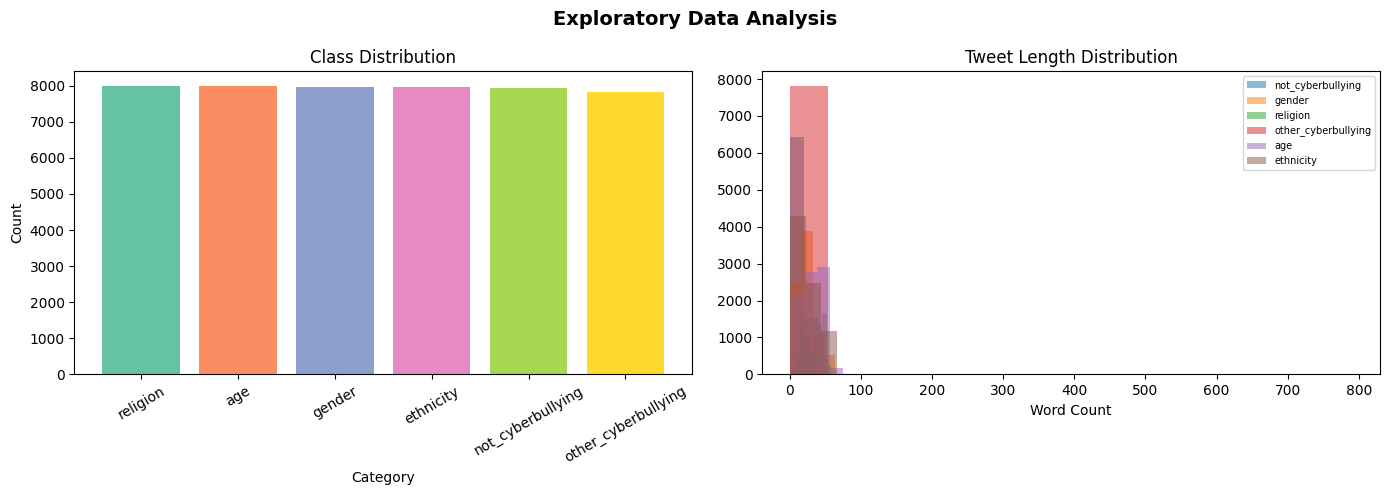

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

counts = df['cyberbullying_type'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
axes[0].set_title('Class Distribution'); axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

df['tweet_len'] = df['tweet_text'].str.split().str.len()
for cat in df['cyberbullying_type'].unique():
    axes[1].hist(df[df['cyberbullying_type']==cat]['tweet_len'], alpha=0.5, label=cat, bins=15)
axes[1].set_title('Tweet Length Distribution'); axes[1].set_xlabel('Word Count'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

# **2️⃣ Text Cleaning & Preprocessing**

🧹 Steps:
- Lowercasing
- Remove URLs
- Remove mentions (@user)
- Remove hashtags (keep word)
- Remove punctuation & numbers
- Remove stopwords
- Tokenization
- Lemmatization

In [7]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # Remove URLs
    text = re.sub(r'@\w+', '', text)                  # Remove mentions
    text = re.sub(r'#(\w+)', r'\1', text)            # Remove # keep word
    text = re.sub(r'\d+', '', text)                   # Remove numbers
    text = text.translate(str.maketrans('', '', __import__('string').punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['tweet_text'].apply(clean_text)
df[['tweet_text', 'clean_text']].head(3)

,tweet_text,clean_text
0,"In other words #katandandre, your food was cra...",word katandandre food crapilicious mkr
1,Why is #aussietv so white? #MKR #theblock #ImA...,aussietv white mkr theblock imacelebrityau tod...
2,@XochitlSuckkks a classy whore? Or more red ve...,classy whore red velvet cupcake


# **Baseline Model — Naive Bayes**
## **3️⃣ Feature Engineering**
## TF-IDF (Baseline Representation)

In [8]:
le = preprocessing.LabelEncoder()
df['label'] = le.fit_transform(df['cyberbullying_type'])
print('Labels:', dict(zip(le.classes_, le.transform(le.classes_))))

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label'].values

Labels: {'age': np.int64(0), 'ethnicity': np.int64(1), 'gender': np.int64(2), 'not_cyberbullying': np.int64(3), 'other_cyberbullying': np.int64(4), 'religion': np.int64(5)}


## **4️⃣ Data Preparation**
## Split the dataset

In [9]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train_nb.shape[0]} | Test: {X_test_nb.shape[0]}')

Train: 38153 | Test: 9539


## Naive Bayes Model Training & Evaluation

In [10]:
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_nb, y_train_nb)
y_pred_nb = nb_model.predict(X_test_nb)

nb_acc = accuracy_score(y_test_nb, y_pred_nb)
print(f'Naive Bayes Accuracy: {nb_acc:.4f}\n')
print(classification_report(y_test_nb, y_pred_nb, target_names=le.classes_))

Naive Bayes Accuracy: 0.7635

                     precision    recall  f1-score   support

                age       0.85      0.95      0.90      1598
          ethnicity       0.91      0.89      0.90      1592
             gender       0.88      0.78      0.83      1595
  not_cyberbullying       0.58      0.44      0.50      1589
other_cyberbullying       0.56      0.57      0.57      1565
           religion       0.76      0.95      0.84      1600

           accuracy                           0.76      9539
          macro avg       0.76      0.76      0.76      9539
       weighted avg       0.76      0.76      0.76      9539



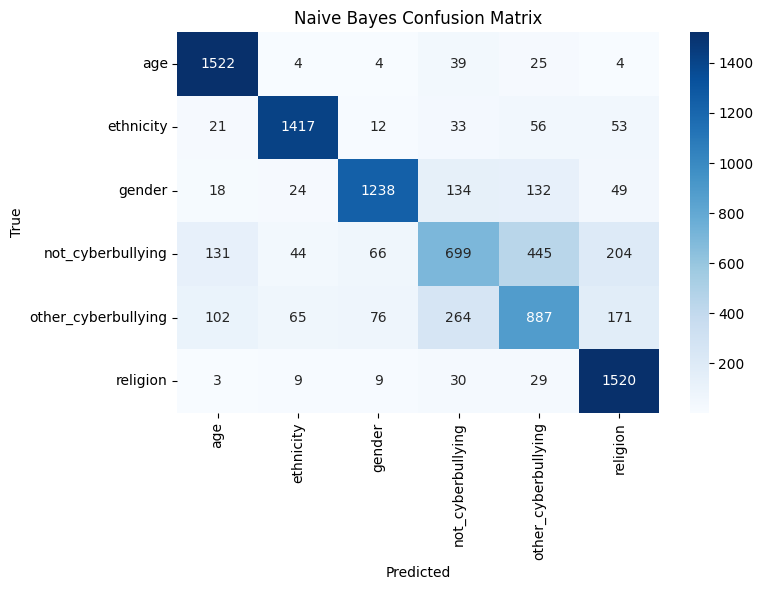

In [11]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_nb, y_pred_nb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues', ax=ax)
ax.set_title('Naive Bayes Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

# **RNN Model**
## **3️⃣ Feature Engineering**
## Sequence Encoding for RNN

In [26]:
MAX_VOCAB = 8000
MAX_LEN = 30
EMBED_DIM = 100
HIDDEN = 128
LAYERS = 2
EPOCHS = 15
BATCH = 32
LR = 1e-3

In [13]:
def build_vocab(texts, max_vocab):
    from collections import Counter
    counter = Counter()
    for t in texts: counter.update(t.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_vocab-2): vocab[word] = len(vocab)
    return vocab

def text_to_seq(text, vocab, max_len):
    tokens = text.split()[:max_len]
    ids = [vocab.get(t, 1) for t in tokens]
    ids += [0] * (max_len - len(ids))
    return ids

In [15]:
texts = df['clean_text'].tolist()
labels = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

vocab = build_vocab(X_train, MAX_VOCAB)
print(f'Vocabulary size: {len(vocab)}')

def encode(t_list):
  return [text_to_seq(t, vocab, MAX_LEN) for t in t_list]

X_tr = torch.tensor(encode(X_train), dtype=torch.long)
X_vl = torch.tensor(encode(X_val),   dtype=torch.long)
X_te = torch.tensor(encode(X_test),  dtype=torch.long)
y_tr = torch.tensor(y_train, dtype=torch.long)
y_vl = torch.tensor(y_val,   dtype=torch.long)
y_te = torch.tensor(y_test,  dtype=torch.long)

Vocabulary size: 8000


## **3.4 GloVe Embeddings**

In [19]:
import gensim.downloader as api
glove_model = api.load('glove-wiki-gigaword-100')   # 100-dim GloVe vectors

[==================================================] 100.0% 128.1/128.1MB downloaded


In [20]:
def embedding_matrix(vocab, glove_model, embed_dim=100):
    matrix = np.zeros((len(vocab), embed_dim))
    for word, idx in vocab.items():
        if word in glove_model:
            matrix[idx] = glove_model[word]
        # else: stays zero (unknown/padding words)
    return torch.tensor(matrix, dtype=torch.float)

embedding_matrix = embedding_matrix(vocab, glove_model)
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: torch.Size([8000, 100])


In [21]:
class TweetDataset(Dataset):
    def __init__(self, X, y): self.X, self.y = X, y
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(TweetDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_vl, y_vl), batch_size=BATCH)
test_loader  = DataLoader(TweetDataset(X_te, y_te), batch_size=BATCH)
print('DataLoaders ready.')

DataLoaders ready.


## RNN Model

In [39]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, n_layers,embedding_matrix, n_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(embedding_matrix, requires_grad=False)
        self.rnn = nn.RNN(embed_dim, hidden,
                          num_layers=n_layers,
                          batch_first=True,
                          dropout=dropout,
                          bidirectional=True)

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden*2, n_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, hn = self.rnn(emb)
        hn = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.fc(self.dropout(hn))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
model = RNNClassifier(len(vocab), EMBED_DIM, HIDDEN, LAYERS, embedding_matrix, n_classes=6).to(device)
print(model)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Device: cuda
RNNClassifier(
  (embedding): Embedding(8000, 100, padding_idx=0)
  (rnn): RNN(100, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)
Params: 159,238


## Model Training

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

In [41]:
def run_epoch(loader, train=True):
    model.train(train)
    total_loss, correct, n = 0, 0, 0
    with torch.set_grad_enabled(train):
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss = criterion(logits, y_b)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()*len(y_b); correct += (logits.argmax(1)==y_b).sum().item(); n += len(y_b)
    return total_loss/n, correct/n

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc, best_state = 0, None

for epoch in range(1, EPOCHS+1):
    t_loss, t_acc = run_epoch(train_loader, train=True)
    v_loss, v_acc = run_epoch(val_loader, train=False)
    scheduler.step(v_loss)
    history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc);   history['val_acc'].append(v_acc)
    print(f'Epoch {epoch:2d}/{EPOCHS} | Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}')

Epoch  1/15 | Train Loss: 0.8191 Acc: 0.6726 | Val Loss: 0.6284 Acc: 0.7338
Epoch  2/15 | Train Loss: 0.6942 Acc: 0.7213 | Val Loss: 0.6122 Acc: 0.7495
Epoch  3/15 | Train Loss: 0.6606 Acc: 0.7364 | Val Loss: 0.5821 Acc: 0.7660
Epoch  4/15 | Train Loss: 0.6287 Acc: 0.7534 | Val Loss: 0.5399 Acc: 0.7783
Epoch  5/15 | Train Loss: 0.6079 Acc: 0.7611 | Val Loss: 0.5095 Acc: 0.7885
Epoch  6/15 | Train Loss: 0.5920 Acc: 0.7666 | Val Loss: 0.5304 Acc: 0.7880
Epoch  7/15 | Train Loss: 0.5770 Acc: 0.7728 | Val Loss: 0.5122 Acc: 0.7925
Epoch  8/15 | Train Loss: 0.5632 Acc: 0.7792 | Val Loss: 0.5079 Acc: 0.7893
Epoch  9/15 | Train Loss: 0.5540 Acc: 0.7814 | Val Loss: 0.4898 Acc: 0.8011
Epoch 10/15 | Train Loss: 0.5532 Acc: 0.7825 | Val Loss: 0.4745 Acc: 0.8139
Epoch 11/15 | Train Loss: 0.5512 Acc: 0.7824 | Val Loss: 0.4799 Acc: 0.8011
Epoch 12/15 | Train Loss: 0.5415 Acc: 0.7835 | Val Loss: 0.4860 Acc: 0.7948
Epoch 13/15 | Train Loss: 0.5355 Acc: 0.7869 | Val Loss: 0.4898 Acc: 0.8074
Epoch 14/15 

## Model Evaluation

In [43]:
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(y_b.numpy())

rnn_acc = accuracy_score(all_labels, all_preds)
print(f'RNN Test Accuracy: {rnn_acc:.4f}\n')
print(classification_report(all_labels, all_preds, target_names=le.classes_))

RNN Test Accuracy: 0.8174

                     precision    recall  f1-score   support

                age       0.99      0.95      0.97      1598
          ethnicity       0.97      0.95      0.96      1592
             gender       0.87      0.79      0.83      1595
  not_cyberbullying       0.66      0.43      0.52      1589
other_cyberbullying       0.56      0.82      0.67      1565
           religion       0.92      0.96      0.94      1600

           accuracy                           0.82      9539
          macro avg       0.83      0.82      0.81      9539
       weighted avg       0.83      0.82      0.82      9539



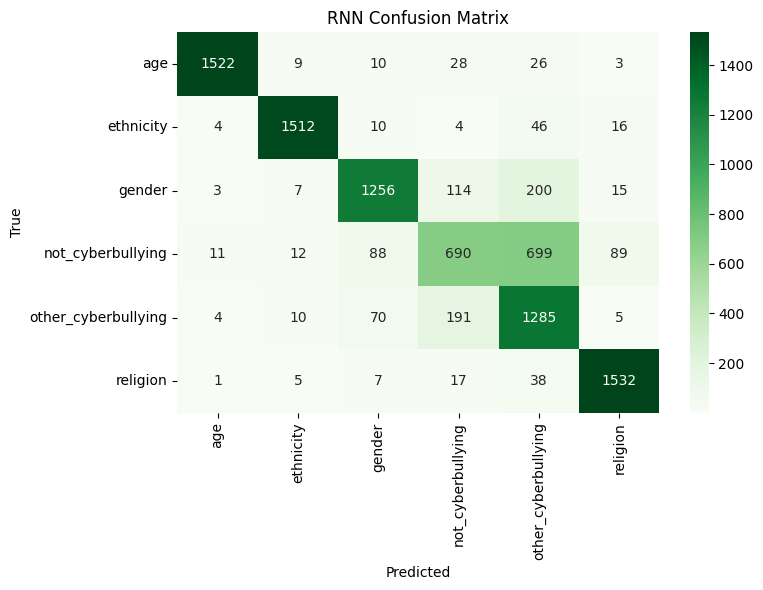

In [44]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Greens', ax=ax)
ax.set_title('RNN Confusion Matrix'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## Plot Loss & Accuracy

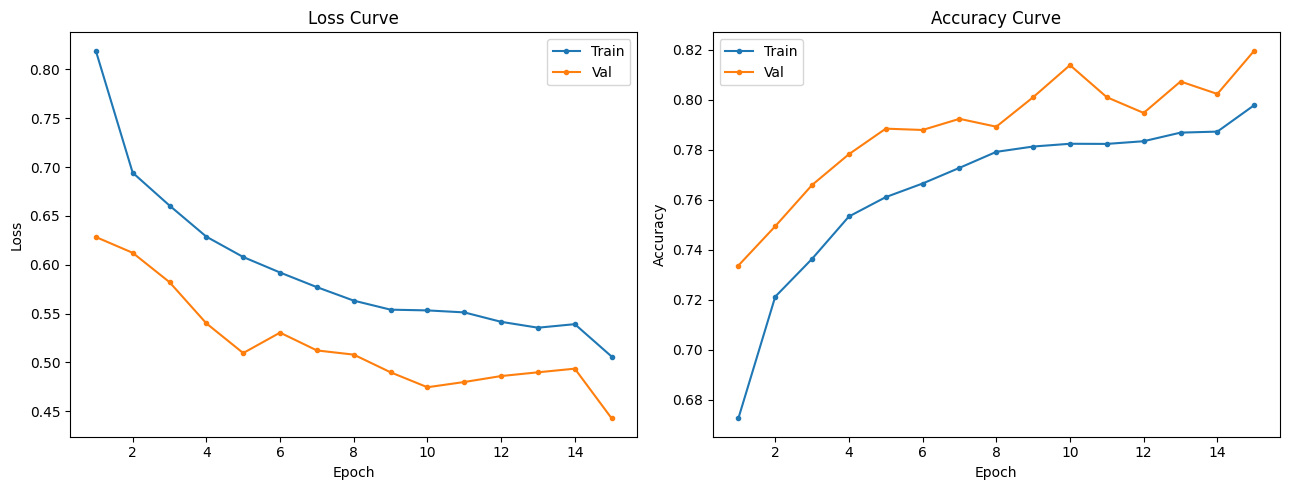

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
ep = range(1, EPOCHS+1)
axes[0].plot(ep, history['train_loss'], label='Train', marker='o', ms=3)
axes[0].plot(ep, history['val_loss'],   label='Val',   marker='o', ms=3)
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(ep, history['train_acc'], label='Train', marker='o', ms=3)
axes[1].plot(ep, history['val_acc'],   label='Val',   marker='o', ms=3)
axes[1].set_title('Accuracy Curve'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

# **Models Comparison**

               Model  Test Accuracy
Naive Bayes (TF-IDF)       0.763497
   Bidirectional RNN       0.817381


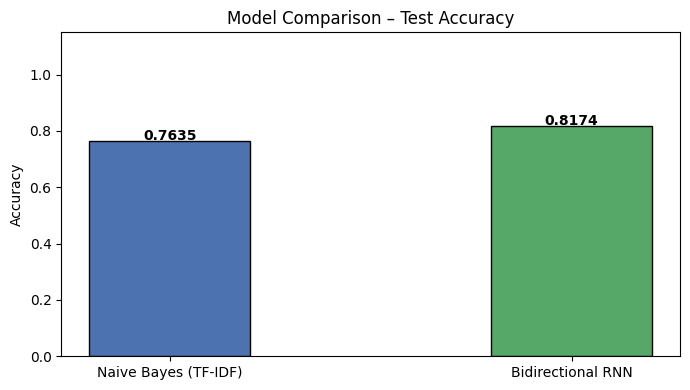

In [46]:
comparison = pd.DataFrame({'Model': ['Naive Bayes (TF-IDF)', 'Bidirectional RNN'],
                           'Test Accuracy': [nb_acc, rnn_acc]})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(comparison['Model'], comparison['Test Accuracy'],
              color=['#4C72B0','#55A868'], width=0.4, edgecolor='black')
for bar, acc in zip(bars, comparison['Test Accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{acc:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0,1.15); ax.set_title('Model Comparison – Test Accuracy'); ax.set_ylabel('Accuracy')
plt.tight_layout(); plt.show()